# IBM Sales Opportunity Win/Loss — Dataset-First Baseline

## 1. Project setup
Estimate historical WON probability, not marketing impact. Run the notebook from top to bottom using one Python kernel with NumPy, pandas, matplotlib and scikit-learn installed. XGBoost is optional; no automatic downloads occur during analysis.

The CSV is loaded from the repository, without uploads or machine-specific paths. In Colab, clone/mount the **whole repository** and change into it first. Package versions and a data fingerprint make this run traceable.

In [1]:
# 1. Repository-relative loading; no upload or network access is required.
from pathlib import Path
import hashlib
import platform
from importlib.metadata import version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

SEED = 42
pd.set_option("display.max_columns", 24)
pd.set_option("display.max_rows", 30)
pd.set_option("display.max_colwidth", 100)

relative_csv = Path("datasets") / "IBM-sales-opportunity.csv"
# Works from the repository root or any directory nested inside it.
candidates = [parent / relative_csv for parent in (Path.cwd(), *Path.cwd().parents)]
data_path = next((path for path in candidates if path.is_file()), None)
if data_path is None:
    raise FileNotFoundError(
        f"Cannot find {relative_csv}. Open/run this notebook inside the cloned repository. "
        "In Colab, clone or mount the whole repository and change into its directory first; "
        "opening only the notebook from GitHub does not copy the CSV."
    )
# 'None' is a real Competitor Type, not a null. Only blank CSV fields are missing.
df = pd.read_csv(data_path, keep_default_na=False, na_values=[""])
ID, TARGET = "Opportunity Number", "Opportunity Result"
assert df[ID].notna().all()
assert set(df[TARGET].unique()) == {"Won", "Loss"}, "Unexpected target labels"
print(f"Dataset: {relative_csv}; dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("CSV SHA-256:", hashlib.sha256(data_path.read_bytes()).hexdigest())
print("Python:", platform.python_version())
for package in ["numpy", "pandas", "scikit-learn", "matplotlib"]:
    print(f"{package}: {version(package)}")
display(df.head(3))

Dataset: datasets/IBM-sales-opportunity.csv; dimensions: 78,025 rows × 19 columns
CSV SHA-256: 31afdb83aa46b54f62f5cdbfe1ccf00f395266254a0249c96ceef8522cc12b24
Python: 3.12.3
numpy: 2.5.3
pandas: 3.0.6
scikit-learn: 1.9.1
matplotlib: 3.11.2


,Opportunity Number,Supplies Subgroup,Supplies Group,Region,Route To Market,Elapsed Days In Sales Stage,Opportunity Result,Sales Stage Change Count,Total Days Identified Through Closing,Total Days Identified Through Qualified,Opportunity Amount USD,Client Size By Revenue,Client Size By Employee Count,Revenue From Client Past Two Years,Competitor Type,Ratio Days Identified To Total Days,Ratio Days Validated To Total Days,Ratio Days Qualified To Total Days,Deal Size Category
0,1641984,Exterior Accessories,Car Accessories,Northwest,Fields Sales,76,Won,13,104,101,0,5,5,0,Unknown,0.69636,0.113985,0.154215,1
1,1658010,Exterior Accessories,Car Accessories,Pacific,Reseller,63,Loss,2,163,163,0,3,5,0,Unknown,0.00000,1.000000,0.000000,1
2,1674737,Motorcycle Parts,Performance & Non-auto,Pacific,Reseller,24,Won,7,82,82,7750,1,1,0,Unknown,1.00000,0.000000,0.000000,1


## 2. Dataset structure and quality
Inspect every column, missing values, representative values and the actual target labels. Preserve the legitimate competitor category `None`; it must not be interpreted as a missing value.

In [2]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(),
    "representative values (most frequent)": [
        ", ".join(map(str, df[c].value_counts().head(5).index)) for c in df
    ],
})
display(audit)
target_distribution = df[TARGET].value_counts().rename("rows").to_frame()
target_distribution["percent"] = 100 * target_distribution["rows"] / len(df)
display(target_distribution.round(2))
print(f"Exact duplicate rows: {df.duplicated().sum():,}")
print(f"Unique opportunity IDs: {df[ID].nunique():,}")
display(df.select_dtypes(include="number").agg(["min", "median", "max"]).T)
print("Categorical domains:")
for column in df.select_dtypes(exclude="number"):
    print(f"{column}: {sorted(df[column].dropna().unique())}")

,dtype,missing,unique,representative values (most frequent)
Opportunity Number,int64,0,77829,"7281765, 8093335, 9782603, 6704540, 6835459"
Supplies Subgroup,str,0,11,"Motorcycle Parts, Exterior Accessories, Garage & Car Care, Shelters & RV, Batteries & Accessories"
Supplies Group,str,0,4,"Car Accessories, Performance & Non-auto, Tires & Wheels, Car Electronics"
Region,str,0,7,"Midwest, Pacific, Northwest, Southeast, Southwest"
Route To Market,str,0,5,"Fields Sales, Reseller, Other, Telesales, Telecoverage"
Elapsed Days In Sales Stage,int64,0,138,"16, 44, 62, 7, 23"
Opportunity Result,str,0,2,"Loss, Won"
Sales Stage Change Count,int64,0,22,"2, 3, 4, 5, 1"
Total Days Identified Through Closing,int64,0,156,"0, 1, 2, 3, 4"
Total Days Identified Through Qualified,int64,0,156,"0, 1, 2, 3, 4"


,rows,percent
Opportunity Result,,
Loss,60398,77.41
Won,17627,22.59


Exact duplicate rows: 55
Unique opportunity IDs: 77,829


,min,median,max
Opportunity Number,1641984.0,7545569.000,10094266.0
Elapsed Days In Sales Stage,0.0,43.000,210.0
Sales Stage Change Count,1.0,3.000,23.0
Total Days Identified Through Closing,0.0,12.000,208.0
Total Days Identified Through Qualified,0.0,12.000,208.0
Opportunity Amount USD,0.0,49000.000,1000000.0
Client Size By Revenue,1.0,1.000,5.0
Client Size By Employee Count,1.0,1.000,5.0
Revenue From Client Past Two Years,0.0,0.000,4.0
Ratio Days Identified To Total Days,0.0,0.000,1.0


Categorical domains:
Supplies Subgroup: ['Batteries & Accessories', 'Car Electronics', 'Exterior Accessories', 'Garage & Car Care', 'Interior Accessories', 'Motorcycle Parts', 'Performance Parts', 'Replacement Parts', 'Shelters & RV', 'Tires & Wheels', 'Towing & Hitches']
Supplies Group: ['Car Accessories', 'Car Electronics', 'Performance & Non-auto', 'Tires & Wheels']
Region: ['Mid-Atlantic', 'Midwest', 'Northeast', 'Northwest', 'Pacific', 'Southeast', 'Southwest']
Route To Market: ['Fields Sales', 'Other', 'Reseller', 'Telecoverage', 'Telesales']
Opportunity Result: ['Loss', 'Won']
Competitor Type: ['Known', 'None', 'Unknown']


## 3. Opportunity identity, redundancy and timing
Distinguish exact copies from nonidentical records sharing an opportunity number. Product differences alone suggest line items, but cannot prove that interpretation. Inspect conflicting outcomes and other changing fields before choosing the unit of prediction. Duration fields are not calendar dates.

In [3]:
counts = df[ID].value_counts()
deduplicated = df.drop_duplicates().copy()
distinct_counts = deduplicated[ID].value_counts()
ambiguous_ids = distinct_counts[distinct_counts > 1].index
repeated = deduplicated[deduplicated[ID].isin(ambiguous_ids)]
variation = repeated.groupby(ID).nunique(dropna=False)
print("Raw repeated IDs:", int((counts > 1).sum()),
      "| Rows in those IDs:", int(counts[counts > 1].sum()))
print("Nonidentical repeated IDs after deduplication:", len(ambiguous_ids),
      "| Rows:", len(repeated))
print("Conflicting outcomes:", int((variation[TARGET] > 1).sum()))
display((variation > 1).sum().rename("IDs with varying values").to_frame())
display(repeated[repeated[ID].isin(ambiguous_ids[:3])].sort_values(ID))

subgroup_mapping = df.groupby("Supplies Subgroup")["Supplies Group"].nunique()
print("Subgroup uniquely determines group:", bool(subgroup_mapping.eq(1).all()))
display(df.groupby("Deal Size Category")["Opportunity Amount USD"].agg(["count", "min", "max"]))
print("Amounts mapping to multiple deal-size categories:", int((
    df.groupby("Opportunity Amount USD")["Deal Size Category"].nunique() > 1
).sum()))
print("Zero amounts:", int(df["Opportunity Amount USD"].eq(0).sum()))
print("No creation/closing/snapshot date or customer ID exists in the 19-column schema.")
print("Elapsed/total days cannot support a chronological split; opportunity ID is not a date.")

Raw repeated IDs: 183 | Rows in those IDs: 379
Nonidentical repeated IDs after deduplication: 137 | Rows: 278
Conflicting outcomes: 0


,IDs with varying values
Supplies Subgroup,46
Supplies Group,20
Region,0
Route To Market,0
Elapsed Days In Sales Stage,0
Opportunity Result,0
Sales Stage Change Count,0
Total Days Identified Through Closing,0
Total Days Identified Through Qualified,0
Opportunity Amount USD,135


,Opportunity Number,Supplies Subgroup,Supplies Group,Region,Route To Market,Elapsed Days In Sales Stage,Opportunity Result,Sales Stage Change Count,Total Days Identified Through Closing,Total Days Identified Through Qualified,Opportunity Amount USD,Client Size By Revenue,Client Size By Employee Count,Revenue From Client Past Two Years,Competitor Type,Ratio Days Identified To Total Days,Ratio Days Validated To Total Days,Ratio Days Qualified To Total Days,Deal Size Category
45759,4787647,Batteries & Accessories,Car Accessories,Southeast,Fields Sales,26,Won,6,49,46,0,1,4,0,Unknown,0.431174,0.293522,0.210526,1
45760,4787647,Shelters & RV,Performance & Non-auto,Southeast,Fields Sales,26,Won,6,49,46,0,1,4,0,Unknown,0.431174,0.293522,0.210526,1
45761,4787647,Interior Accessories,Car Accessories,Southeast,Fields Sales,26,Won,6,49,46,6000,1,4,0,Unknown,0.431174,0.293522,0.210526,1
10488,6835459,Replacement Parts,Car Accessories,Pacific,Fields Sales,90,Won,1,0,0,56073,1,1,0,Unknown,0.000000,0.000000,0.000000,4
10490,6835459,Replacement Parts,Car Accessories,Pacific,Fields Sales,90,Won,1,0,0,9281,1,1,0,Unknown,0.000000,0.000000,0.000000,1
10489,6835459,Replacement Parts,Car Accessories,Pacific,Fields Sales,90,Won,1,0,0,41964,1,1,0,Unknown,0.000000,0.000000,0.000000,3
18755,7281765,Batteries & Accessories,Car Accessories,Pacific,Reseller,66,Won,4,8,5,45000,5,1,0,Known,0.000000,0.320000,0.333333,3
18753,7281765,Batteries & Accessories,Car Accessories,Pacific,Reseller,66,Won,4,8,5,15000,5,1,0,Known,0.000000,0.320000,0.333333,2
18754,7281765,Batteries & Accessories,Car Accessories,Pacific,Reseller,66,Won,4,8,5,60000,5,1,0,Known,0.000000,0.320000,0.333333,4


Subgroup uniquely determines group: True


,count,min,max
Deal Size Category,,,
1,12095,0,9999
2,15123,10000,24999
3,11968,25000,49999
4,13628,50000,99999
5,18074,100000,249999
6,4934,250000,499999
7,2203,500000,1000000


Amounts mapping to multiple deal-size categories: 0
Zero amounts: 2047
No creation/closing/snapshot date or customer ID exists in the 19-column schema.
Elapsed/total days cannot support a chronological split; opportunity ID is not a date.


## 4. Prediction point and feature policy
**Scoring point:** initial opportunity registration, after the proposed product, territory and initial sales route have been recorded, but before qualification/progression. Estimate eventual `Won` among comparable historical resolved opportunities. The CSV has no snapshots: even these initial values cannot be verified retrospectively.

### SAFE PRE-PREDICTION FEATURES
- **Supplies Subgroup, Region, Route To Market:** plausible registration inputs under the definition above. Route means the existing sales route, not an optimal contact channel. These three form the conservative primary model.

### QUESTIONABLE / REQUIRES BUSINESS ASSUMPTION
- **Opportunity Amount USD / Log Opportunity Amount:** initial estimate could exist, but this export may contain a revised/final amount. Zero may mean unknown; log transformation does not remove leakage.
- **Client Size By Revenue / Employee Count:** usable only if profiles/bands existed at scoring time. Codes 1–5 have no supplied band definitions; encode as categories, not measured revenue or headcount.
- **Revenue From Client Past Two Years:** codes 0–4, not dollar amounts. Requires a lookback ending before scoring. Zero is not proven to mean a new customer; existing customers can have no recent purchases. No customer ID/new-customer flag validates cold-start performance.
- **Competitor Type:** often discovered during qualification, not creation. `Unknown`, `Known` and `None` are distinct; later updates could encode progression. Excluded from the primary model regardless of accuracy.

### EXCLUDE / LEAKAGE / IDENTIFIER
- **Opportunity Number:** grouping/audit identifier; **Opportunity Result:** target only.
- **Supplies Group:** exactly determined by subgroup. **Deal Size Category:** deterministic amount bands; redundant and inherits amount-timing risk.
- **Elapsed Days In Sales Stage, Sales Stage Change Count, Total Days Identified Through Closing/Qualified, all three Ratio Days fields:** progression/future-duration information, unavailable at the chosen scoring point. Duration ratios can indirectly encode outcome/progression; exclude rather than justify by predictive power.

After 55 exact copies are removed, 137 IDs retain nonidentical rows (278 rows). Differences are consistent with line items, not demonstrated snapshots; there is no item/date key. Exclude these ambiguous IDs for a **single-record-opportunity** baseline, report the selection effect, and do not generalize to multi-item opportunities.

In [4]:
model_df = deduplicated.loc[~deduplicated[ID].isin(ambiguous_ids)].copy()
model_df["target"] = model_df[TARGET].map({"Won": 1, "Loss": 0}).astype(int)
assert model_df[ID].is_unique
assert model_df["Opportunity Amount USD"].ge(0).all()
features = ["Supplies Subgroup", "Region", "Route To Market"]
profile_features = ["Client Size By Revenue", "Client Size By Employee Count"]
history_feature = "Revenue From Client Past Two Years"
amount_feature = "Opportunity Amount USD"
print("Primary features:", features)
print(f"Retained {len(model_df):,} single-record opportunities; excluded {len(ambiguous_ids):,} ambiguous IDs")
selection_audit = pd.DataFrame({
    "opportunities": [df[ID].nunique(), len(ambiguous_ids), len(model_df)],
    "WON rate": [df.drop_duplicates(ID)[TARGET].eq("Won").mean(),
                 repeated.drop_duplicates(ID)[TARGET].eq("Won").mean(),
                 model_df["target"].mean()],
}, index=["All unique IDs", "Excluded nonidentical IDs", "Retained IDs"])
display(selection_audit.round(4))
display(model_df[TARGET].value_counts().rename("retained opportunities").to_frame())

Primary features: ['Supplies Subgroup', 'Region', 'Route To Market']
Retained 77,692 single-record opportunities; excluded 137 ambiguous IDs


,opportunities,WON rate
All unique IDs,77829,0.2255
Excluded nonidentical IDs,137,0.3504
Retained IDs,77692,0.2252


,retained opportunities
Opportunity Result,
Loss,60192
Won,17500


## 5. Leakage-aware evaluation split
Use separate **training (~50%), calibration (~10%), validation (~20%) and final test (~20%)** partitions. All splits are grouped by opportunity ID and approximately stratified. Even though ambiguous IDs were excluded, explicit overlap assertions protect future revisions.

There are no calendar dates, so chronological validation is impossible. Customer-level overlap also cannot be checked without a customer ID. Preprocessing is fitted only on training data; calibration is fitted separately, and validation chooses the model/probability variant and classification threshold. The final test is not used for those choices.

In [5]:
from itertools import combinations
from sklearn.model_selection import StratifiedGroupKFold

def grouped_holdout(frame, folds, seed):
    splitter = StratifiedGroupKFold(n_splits=folds, shuffle=True, random_state=seed)
    keep, holdout = next(splitter.split(frame[features], frame["target"], groups=frame[ID]))
    return frame.iloc[keep].copy(), frame.iloc[holdout].copy()

development_df, test_df = grouped_holdout(model_df, 5, SEED)
fit_df, validation_df = grouped_holdout(development_df, 4, SEED + 1)
train_df, calibration_df = grouped_holdout(fit_df, 6, SEED + 2)
partitions = {"train": train_df, "calibration": calibration_df,
              "validation": validation_df, "test": test_df}
for (name_a, a), (name_b, b) in combinations(partitions.items(), 2):
    assert set(a[ID]).isdisjoint(b[ID]), f"ID overlap: {name_a}/{name_b}"
assert sum(map(len, partitions.values())) == len(model_df)
display(pd.DataFrame([
    {"partition": name, "opportunities": len(frame), "WON rate": frame["target"].mean()}
    for name, frame in partitions.items()
 ]).set_index("partition").round(4))
print("All six pairwise opportunity-ID overlap checks passed.")
for name, frame in partitions.items():
    for column in features + profile_features + [history_feature, "Competitor Type"]:
        unseen = set(frame[column].dropna()) - set(train_df[column].dropna())
        assert not unseen, f"Unseen {column} in {name}: {unseen}"
print("All evaluated categorical values occur in training data.")
X_train, y_train = train_df[features], train_df["target"]
X_validation, y_validation = validation_df[features], validation_df["target"]
X_test, y_test = test_df[features], test_df["target"]

,opportunities,WON rate
partition,,
train,38846,0.2252
calibration,7769,0.2253
validation,15538,0.2253
test,15539,0.2252


All six pairwise opportunity-ID overlap checks passed.
All evaluated categorical values occur in training data.


## 6. Baseline models and preprocessing
Compare a prevalence-only baseline, Logistic Regression and a regularized Random Forest. Include XGBoost only if already installed; otherwise state that it was not tested. Categorical encoding rejects unknown categories instead of silently assigning all-zero vectors. Numeric sensitivity features use median imputation, log amount and scaling inside the pipeline.

Keep the natural ~22.5% WON prevalence: no SMOTE or automatic class weighting, which can distort probability estimates. Use PR-AUC (average precision), ROC-AUC, Brier score and log loss; report classification metrics at 0.5 here. Hyperparameters are fixed, not tuned against test results.

In [6]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
    recall_score, f1_score, brier_score_loss, log_loss, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay)

def make_pipeline(estimator, categorical, numeric=None):
    numeric = numeric or []
    transformers = [("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="error", sparse_output=False)),
    ]), categorical)]
    if numeric:
        transformers.append(("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
            ("scale", StandardScaler()),
        ]), numeric))
    return Pipeline([("preprocess", ColumnTransformer(transformers)),
                     ("model", clone(estimator))])

def metrics(y, probability, threshold=0.5):
    prediction = np.asarray(probability) >= threshold
    return {"ROC-AUC": roc_auc_score(y, probability),
            "PR-AUC (AP)": average_precision_score(y, probability),
            "precision": precision_score(y, prediction, zero_division=0),
            "recall": recall_score(y, prediction, zero_division=0),
            "F1": f1_score(y, prediction, zero_division=0),
            "Brier": brier_score_loss(y, probability),
            "log loss": log_loss(y, probability)}

estimators = {
    "Prevalence baseline": DummyClassifier(strategy="prior"),
    "Logistic Regression": LogisticRegression(max_iter=1500, C=1.0, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12,
        min_samples_leaf=30, max_features=0.8, n_jobs=2, random_state=SEED),
}
try:
    from xgboost import XGBClassifier
except ImportError:
    print("XGBoost not installed: comparison skipped; no download needed to run this notebook.")
else:
    estimators["XGBoost"] = XGBClassifier(n_estimators=250, max_depth=3,
        learning_rate=0.05, min_child_weight=10, subsample=0.9, colsample_bytree=0.9,
        reg_lambda=5, objective="binary:logistic", eval_metric="logloss",
        tree_method="hist", n_jobs=2, random_state=SEED)
    print("XGBoost version:", version("xgboost"))

models, validation_rows = {}, []
for name, estimator in estimators.items():
    fitted = make_pipeline(estimator, features).fit(X_train, y_train)
    models[name] = fitted
    p = fitted.predict_proba(X_validation)[:, 1]
    validation_rows.append({"model": name, **metrics(y_validation, p)})
validation_comparison = pd.DataFrame(validation_rows).set_index("model")
display(validation_comparison.round(4))

XGBoost not installed: comparison skipped; no download needed to run this notebook.


,ROC-AUC,PR-AUC (AP),precision,recall,F1,Brier,log loss
model,,,,,,,
Prevalence baseline,0.5000,0.2253,0.0,0.0,0.0,0.1745,0.5335
Logistic Regression,0.6006,0.3021,0.0,0.0,0.0,0.1706,0.5223
Random Forest,0.6125,0.3067,0.0,0.0,0.0,0.1694,0.5191


## 7. Feature assumptions and the old “cold-start” model
Validation-only sensitivity tests add customer bands, amount, history, then competitor status to the same Random Forest. These are **not eligible for the primary model**: better performance cannot establish when a value became known.

Removing history is an availability ablation, not proof of new-customer performance. Removing region does not establish transfer to another industry. The old generic/ERP example was unsupported; this dataset contains automotive/accessory product categories. Supplies Group and Deal Size Category remain excluded as redundant.

In [7]:
sensitivity_sets = {
    "Primary: registration only": (features, []),
    "+ client profile bands": (features + profile_features, []),
    "+ amount, no history (not validated cold-start)": (features + profile_features, [amount_feature]),
    "+ historical revenue band": (features + profile_features + [history_feature], [amount_feature]),
    "+ competitor (timing risk)": (features + profile_features + [history_feature, "Competitor Type"], [amount_feature]),
}
sensitivity_rows = []
for name, (categorical, numeric) in sensitivity_sets.items():
    columns = categorical + numeric
    if name.startswith("Primary"):
        fitted = models["Random Forest"]
    else:
        fitted = make_pipeline(estimators["Random Forest"], categorical, numeric)
        fitted.fit(train_df[columns], y_train)
    p = fitted.predict_proba(validation_df[columns])[:, 1]
    sensitivity_rows.append({"feature assumption": name, "features": len(columns),
                             **metrics(y_validation, p)})
sensitivity_comparison = pd.DataFrame(sensitivity_rows).set_index("feature assumption")
display(sensitivity_comparison.round(4))
print("Training-only checks: associations are not evidence of pre-prediction availability.")
for column in [history_feature, "Competitor Type"]:
    display(train_df.groupby(column)["target"].agg(["count", "mean"]).round(4))
display(train_df.assign(zero_amount=train_df[amount_feature].eq(0))
        .groupby("zero_amount")["target"].agg(["count", "mean"]).round(4))

,features,ROC-AUC,PR-AUC (AP),precision,recall,F1,Brier,log loss
feature assumption,,,,,,,,
Primary: registration only,3,0.6125,0.3067,0.0000,0.0000,0.0000,0.1694,0.5191
+ client profile bands,5,0.6189,0.3171,0.6250,0.0043,0.0085,0.1688,0.5174
"+ amount, no history (not validated cold-start)",6,0.7834,0.4886,0.5844,0.1909,0.2877,0.1435,0.4433
+ historical revenue band,7,0.8206,0.5978,0.6938,0.3171,0.4353,0.1292,0.4080
+ competitor (timing risk),8,0.8195,0.5984,0.6948,0.3174,0.4358,0.1294,0.4086


Training-only checks: associations are not evidence of pre-prediction availability.


,count,mean
Revenue From Client Past Two Years,,
0,34469,0.1739
1,880,0.8125
2,1037,0.7242
3,1043,0.6184
4,1417,0.4552


,count,mean
Competitor Type,,
Known,5935,0.1916
None,4603,0.3122
Unknown,28308,0.2182


,count,mean
zero_amount,,
False,37855,0.2272
True,991,0.1524


## 8. Probability calibration and model selection
Fit a sigmoid mapping of each model’s log-odds using **only the calibration partition**. Compare raw and calibrated probabilities on validation data; select the lowest validation Brier score (log loss breaks ties). Calibration is not automatically an improvement.

Choose a validation F1-maximizing threshold separately for illustration. It is not a business-optimal threshold: no contact cost, intervention benefit or capacity constraint is supplied. Probability estimates are independent of this classification cutoff.

In [8]:
from sklearn.metrics import precision_recall_curve

def log_odds(probability):
    p = np.clip(np.asarray(probability, dtype=float), 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p)).reshape(-1, 1)

candidates, calibration_rows = {}, []
for name, fitted in models.items():
    raw_val = fitted.predict_proba(X_validation)[:, 1]
    candidates[name + " | raw"] = (fitted, None)
    calibration_rows.append({"candidate": name + " | raw", **metrics(y_validation, raw_val)})
    if name == "Prevalence baseline":
        continue
    raw_cal = fitted.predict_proba(calibration_df[features])[:, 1]
    calibrator = LogisticRegression(C=1e6, solver="lbfgs", max_iter=1000)
    calibrator.fit(log_odds(raw_cal), calibration_df["target"])
    cal_val = calibrator.predict_proba(log_odds(raw_val))[:, 1]
    candidates[name + " | sigmoid"] = (fitted, calibrator)
    calibration_rows.append({"candidate": name + " | sigmoid", **metrics(y_validation, cal_val)})

calibration_comparison = pd.DataFrame(calibration_rows).set_index("candidate")
calibration_comparison = calibration_comparison.sort_values(["Brier", "log loss"])
display(calibration_comparison.round(5))
chosen_name = calibration_comparison.index[0]
final_pipeline, final_calibrator = candidates[chosen_name]

def final_probability(frame):
    raw = final_pipeline.predict_proba(frame[features])[:, 1]
    if final_calibrator is None:
        return raw
    return final_calibrator.predict_proba(log_odds(raw))[:, 1]

validation_probability = final_probability(validation_df)
prec, rec, thresholds = precision_recall_curve(y_validation, validation_probability)
f1_values = 2 * prec[:-1] * rec[:-1] / np.maximum(prec[:-1] + rec[:-1], 1e-12)
chosen_threshold = float(thresholds[np.argmax(f1_values)])
print("Locked primary model:", chosen_name)
print(f"Validation-selected F1 threshold: {chosen_threshold:.4f}")
print("The final test has not been used for training, calibration, model selection or threshold selection.")

,ROC-AUC,PR-AUC (AP),precision,recall,F1,Brier,log loss
candidate,,,,,,,
Random Forest | raw,0.61249,0.30672,0.0,0.0,0.0,0.16945,0.51914
Random Forest | sigmoid,0.61249,0.30672,0.0,0.0,0.0,0.16951,0.51934
Logistic Regression | sigmoid,0.60059,0.30212,0.0,0.0,0.0,0.17058,0.52236
Logistic Regression | raw,0.60059,0.30212,0.0,0.0,0.0,0.17060,0.52231
Prevalence baseline | raw,0.50000,0.22525,0.0,0.0,0.0,0.17451,0.53348


Locked primary model: Random Forest | raw
Validation-selected F1 threshold: 0.1844
The final test has not been used for training, calibration, model selection or threshold selection.


## 9. Final held-out evaluation
Evaluate the locked conservative model once on the test opportunities. Report both the conventional 0.5 cutoff and the validation-selected cutoff; compare with the training-prevalence probability baseline. ROC/PR measure ranking, while Brier/log loss measure probability quality.

A well-calibrated model can still rank poorly. Bootstrap intervals below reflect test-sample uncertainty for a fixed fitted model—not training variability, temporal drift or deployment validity.

,ROC-AUC,PR-AUC (AP),precision,recall,F1,Brier,log loss
evaluation,,,,,,,
Prevalence baseline @ 0.5,0.5000,0.2252,0.0000,0.0000,0.0000,0.1745,0.5335
Primary @ 0.5,0.6188,0.3105,0.0000,0.0000,0.0000,0.1689,0.5177
Primary @ 0.1844,0.6188,0.3105,0.2656,0.7523,0.3926,0.1689,0.5177


Brier skill vs prevalence: 3.19%
Test predicted range: 3.3%–42.5%
Confusion matrices: rows actual [Loss, Won], columns predicted [Loss, Won]
At 0.5:
 [[12039     0]
 [ 3500     0]]
At selected threshold:
 [[4760 7279]
 [ 867 2633]]


,95% lower,95% upper
ROC-AUC,0.6078,0.6301
PR-AUC (AP),0.2987,0.3233
Brier,0.1648,0.1726


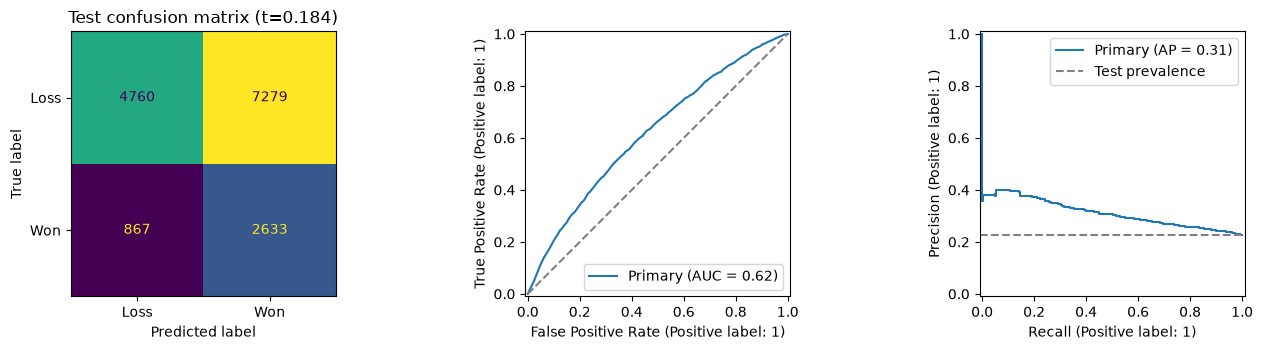

In [9]:
test_probability = final_probability(test_df)
baseline_probability = np.full(len(test_df), y_train.mean())
test_metrics = pd.DataFrame([
    {"evaluation": "Prevalence baseline @ 0.5", **metrics(y_test, baseline_probability)},
    {"evaluation": "Primary @ 0.5", **metrics(y_test, test_probability)},
    {"evaluation": f"Primary @ {chosen_threshold:.4f}",
     **metrics(y_test, test_probability, chosen_threshold)},
 ]).set_index("evaluation")
display(test_metrics.round(4))
final_metrics = metrics(y_test, test_probability, chosen_threshold)
brier_skill = 1 - final_metrics["Brier"] / brier_score_loss(y_test, baseline_probability)
print(f"Brier skill vs prevalence: {brier_skill:.2%}")
print(f"Test predicted range: {test_probability.min():.1%}–{test_probability.max():.1%}")
print("Confusion matrices: rows actual [Loss, Won], columns predicted [Loss, Won]")
print("At 0.5:\n", confusion_matrix(y_test, test_probability >= 0.5, labels=[0, 1]))
print("At selected threshold:\n", confusion_matrix(y_test, test_probability >= chosen_threshold, labels=[0, 1]))

rng = np.random.default_rng(SEED)
y_array = y_test.to_numpy()
bootstrap = []
for _ in range(200):
    indices = rng.integers(0, len(y_array), size=len(y_array))
    y_b, p_b = y_array[indices], test_probability[indices]
    bootstrap.append([roc_auc_score(y_b, p_b), average_precision_score(y_b, p_b),
                      brier_score_loss(y_b, p_b)])
display(pd.DataFrame(np.quantile(bootstrap, [0.025, 0.975], axis=0).T,
    index=["ROC-AUC", "PR-AUC (AP)", "Brier"], columns=["95% lower", "95% upper"]).round(4))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
ConfusionMatrixDisplay.from_predictions(y_test, test_probability >= chosen_threshold,
    display_labels=["Loss", "Won"], ax=axes[0], colorbar=False)
axes[0].set_title(f"Test confusion matrix (t={chosen_threshold:.3f})")
RocCurveDisplay.from_predictions(y_test, test_probability, ax=axes[1], name="Primary")
axes[1].plot([0, 1], [0, 1], "--", color="grey")
PrecisionRecallDisplay.from_predictions(y_test, test_probability, ax=axes[2], name="Primary")
axes[2].axhline(y_test.mean(), ls="--", color="grey", label="Test prevalence")
axes[2].legend()
plt.tight_layout()
plt.show()

## 10. Are the probabilities meaningful?
For each fixed 10-percentage-point probability bin, compare the mean prediction with the historical WON rate. Counts refer to **unique test opportunities**. Empty bins remain visible; they are not evidence of calibration. Bins include the upper bound (the first also includes zero).

Wilson 95% intervals describe uncertainty in the observed bin win rate, not an individual opportunity’s outcome. Expected calibration error (ECE) is a bin-dependent diagnostic, not a deployment guarantee. The quantile curve gives more detail over the model’s narrow score range.

,opportunities,mean_predicted,observed_WON_rate,observed_95%_low,observed_95%_high,absolute_gap
probability bin,,,,,,
0–10%,205,0.0636,0.0585,0.0338,0.0995,0.0051
10–20%,6604,0.1611,0.1652,0.1564,0.1744,0.0041
20–30%,5967,0.2455,0.2407,0.2300,0.2517,0.0049
30–40%,2749,0.3470,0.3478,0.3302,0.3658,0.0008
40–50%,14,0.4253,0.3571,0.1634,0.6124,0.0681
50–60%,0,NaN,NaN,NaN,NaN,NaN
60–70%,0,NaN,NaN,NaN,NaN,NaN
70–80%,0,NaN,NaN,NaN,NaN,NaN
80–90%,0,NaN,NaN,NaN,NaN,NaN


Test mean prediction: 22.54%; observed WON rate: 22.52%
10-bin ECE: 0.0039 (0.39 percentage points)
Empty-bin rates are undefined (NaN), not zero.


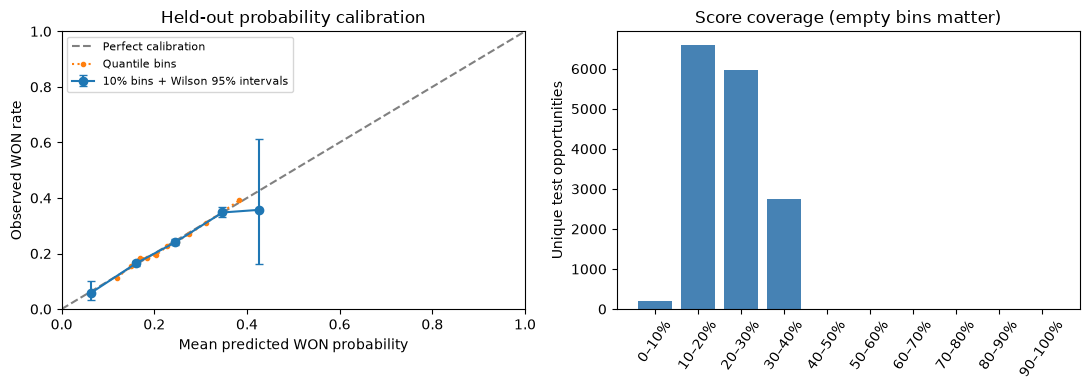

In [14]:
from sklearn.calibration import calibration_curve

bin_labels = [f"{lower}–{lower + 10}%" for lower in range(0, 100, 10)]
test_scores = pd.DataFrame({
    ID: test_df[ID].to_numpy(), "predicted": test_probability, "won": y_test.to_numpy(),
})
assert test_scores[ID].is_unique
assert np.isfinite(test_probability).all() and ((test_probability >= 0) & (test_probability <= 1)).all()
test_scores["probability bin"] = pd.cut(test_scores["predicted"],
    bins=np.linspace(0, 1, 11), labels=bin_labels, include_lowest=True)
calibration_table = test_scores.groupby("probability bin", observed=False).agg(
    opportunities=(ID, "size"), mean_predicted=("predicted", "mean"),
    observed_WON_rate=("won", "mean"))

assert calibration_table["opportunities"].sum() == len(test_df)
n = calibration_table["opportunities"].replace(0, np.nan)
rate = calibration_table["observed_WON_rate"]
z = 1.96
center = (rate + z**2 / (2 * n)) / (1 + z**2 / n)
half_width = z * np.sqrt(rate * (1 - rate) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
calibration_table["observed_95%_low"] = center - half_width
calibration_table["observed_95%_high"] = center + half_width
calibration_table["absolute_gap"] = (rate - calibration_table["mean_predicted"]).abs()
ece = (calibration_table["opportunities"] * calibration_table["absolute_gap"]).sum() / len(test_df)
display(calibration_table.round(4))
print(f"Test mean prediction: {test_probability.mean():.2%}; observed WON rate: {y_test.mean():.2%}")
print(f"10-bin ECE: {ece:.4f} ({100 * ece:.2f} percentage points)")
print("Empty-bin rates are undefined (NaN), not zero.")

populated = calibration_table.loc[calibration_table["opportunities"] > 0]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot([0, 1], [0, 1], "--", color="grey", label="Perfect calibration")
axes[0].errorbar(populated["mean_predicted"], populated["observed_WON_rate"],
    yerr=[populated["observed_WON_rate"] - populated["observed_95%_low"],
          populated["observed_95%_high"] - populated["observed_WON_rate"]],
    fmt="o-", capsize=3, label="10% bins + Wilson 95% intervals")
observed_q, predicted_q = calibration_curve(y_test, test_probability, n_bins=10, strategy="quantile")
axes[0].plot(predicted_q, observed_q, ".:", label="Quantile bins")
axes[0].set(xlim=(0, 1), ylim=(0, 1), xlabel="Mean predicted WON probability",
            ylabel="Observed WON rate", title="Held-out probability calibration")
axes[0].legend(fontsize=8)
axes[1].bar(bin_labels, calibration_table["opportunities"], color="steelblue")
axes[1].tick_params(axis="x", rotation=55)
axes[1].set(ylabel="Unique test opportunities", title="Score coverage (empty bins matter)")
plt.tight_layout()
plt.show()

## 11. Genuine held-out opportunities
Select low, middle and high **relative scores** from the test set using predicted probabilities only—not outcomes. Display all three model inputs and the historical result. The conservative model produces no scores above 50%, so “high” here does not mean “likely to win.” These examples illustrate predictions; they do not validate individual probabilities.

In [11]:
example_positions = [int(np.argmin(test_probability)),
    int(np.argmin(np.abs(test_probability - np.median(test_probability)))),
    int(np.argmax(test_probability))]
assert len(set(example_positions)) == 3
heldout_examples = test_df.iloc[example_positions][[ID] + features + [TARGET]].copy()
heldout_examples.insert(0, "score example", ["Low (minimum)", "Middle (near median)", "High (maximum)"])
heldout_examples["predicted WON probability"] = test_probability[example_positions]
heldout_examples["training rows with same inputs"] = [
    int(train_df[features].eq(row[features]).all(axis=1).sum())
    for _, row in heldout_examples.iterrows()
 ]
assert set(heldout_examples[ID]).isdisjoint(train_df[ID])
display(heldout_examples.reset_index(drop=True).round(4))
print("These are real held-out records. IDs and outcomes are displayed for audit only, never model inputs.")

,score example,Opportunity Number,Supplies Subgroup,Region,Route To Market,Opportunity Result,predicted WON probability,training rows with same inputs
0,Low (minimum),6875048,Interior Accessories,Pacific,Telecoverage,Loss,0.0331,46
1,Middle (near median),5524921,Exterior Accessories,Southeast,Fields Sales,Loss,0.2144,345
2,High (maximum),7349654,Tires & Wheels,Midwest,Reseller,Loss,0.4253,46


These are real held-out records. IDs and outcomes are displayed for audit only, never model inputs.


## 12. Manual input and prediction safeguards
Enter an automotive-product example using only categories observed in training. Validate the exact schema, reject missing/unknown categories and reject entirely unseen input combinations for this demonstration. Low training support is explicitly flagged; known categories alone do not establish real-world validity.

The example is hypothetical and has no historical outcome. An unseen-category negative test must **fail before predicting**—a warning followed by a numeric score is not sufficient. No ERP/software/online categories are invented.

In [12]:
encoder = final_pipeline.named_steps["preprocess"].named_transformers_["categorical"].named_steps["encoder"]
known_categories = dict(zip(features, encoder.categories_))

def checked_prediction(inputs):
    if inputs.empty or inputs.columns.has_duplicates or set(inputs.columns) != set(features):
        raise ValueError(f"Supply exactly these nonduplicated feature columns: {features}")
    if inputs.isna().any().any():
        raise ValueError("Missing input: collect the registration information before scoring.")
    for column, allowed in known_categories.items():
        invalid = inputs.loc[~inputs[column].isin(allowed), column].unique().tolist()
        if invalid:
            raise ValueError(f"Unseen values in {column}: {invalid}; no prediction returned.")
    support = [int(train_df[features].eq(row[features]).all(axis=1).sum())
               for _, row in inputs.iterrows()]
    if min(support) == 0:
        raise ValueError("Input combination never seen in training; manual review required.")
    result = inputs[features].copy()
    result["estimated WON probability"] = final_probability(inputs)
    result["training support"] = support
    result["support note"] = ["Limited support: review" if n < 50 else "Observed combination" for n in support]
    return result

manual_input = pd.DataFrame([{
    "Supplies Subgroup": "Exterior Accessories",
    "Region": "Northwest",
    "Route To Market": "Fields Sales",
}])
display(checked_prediction(manual_input).round(4))
print("Manual example: no actual outcome exists; probability is an experimental historical estimate.")

negative_tests = {}
for column in features:
    invalid = manual_input.copy()
    invalid[column] = "__UNSEEN_TEST_VALUE__"
    negative_tests[f"unseen {column}"] = invalid
negative_tests["missing column"] = manual_input.drop(columns=features[0])
negative_tests["extra column"] = manual_input.assign(unexpected_input="invalid")
negative_tests["null input"] = manual_input.copy().assign(Region=None)
for description, invalid in negative_tests.items():
    try:
        checked_prediction(invalid)
    except ValueError as error:
        print(f"PASS — rejected {description}: {error}")
    else:
        raise AssertionError(f"Input validation failed: {description}")

# The pipeline itself must reject unknown categories too, even if the wrapper is bypassed.
try:
    final_probability(negative_tests["unseen Region"])
except ValueError:
    print("PASS — underlying encoder also rejects unknown categories.")
else:
    raise AssertionError("Encoder silently accepted an unknown category")

,Supplies Subgroup,Region,Route To Market,estimated WON probability,training support,support note
0,Exterior Accessories,Northwest,Fields Sales,0.2111,446,Observed combination


Manual example: no actual outcome exists; probability is an experimental historical estimate.
PASS — rejected unseen Supplies Subgroup: Unseen values in Supplies Subgroup: ['__UNSEEN_TEST_VALUE__']; no prediction returned.
PASS — rejected unseen Region: Unseen values in Region: ['__UNSEEN_TEST_VALUE__']; no prediction returned.
PASS — rejected unseen Route To Market: Unseen values in Route To Market: ['__UNSEEN_TEST_VALUE__']; no prediction returned.
PASS — rejected missing column: Supply exactly these nonduplicated feature columns: ['Supplies Subgroup', 'Region', 'Route To Market']
PASS — rejected extra column: Supply exactly these nonduplicated feature columns: ['Supplies Subgroup', 'Region', 'Route To Market']
PASS — rejected null input: Missing input: collect the registration information before scoring.
PASS — underlying encoder also rejects unknown categories.


## 13. Explainability and final checks
Use held-out permutation importance on the **original input columns**, measured as the increase in Brier loss after shuffling one feature. This explains predictive reliance, not causation or percentage-point changes in win probability. Correlated inputs and unrealistic shuffled combinations can affect the result; repeat variability is not a causal confidence interval.

**SHAP review:** the old XGBoost TreeExplainer used raw output (normally log-odds), not probability-point contributions, and explained unsupported categories. It also imported SHAP before its installation cell. Those examples and installation cells are removed. SHAP is not needed for this three-input baseline; permutation importance provides simpler, tested global explainability without another dependency. No local causal explanation is claimed.

,Brier loss increase,repeat SD
feature,,
Supplies Subgroup,0.00555,0.00042
Route To Market,0.00516,0.00056
Region,0.00317,0.00012


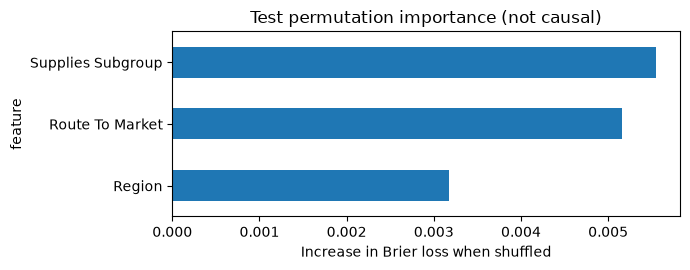

Final checks passed: selected features only; no ID overlap; stable predictions; unique opportunity counts.
All analysis uses the repository CSV. No model artifacts, new app, commits or pushes are created.


In [13]:
from sklearn.inspection import permutation_importance

def probability_quality(estimator, inputs, outcome):
    p = estimator.predict_proba(inputs)[:, 1]
    if final_calibrator is not None:
        p = final_calibrator.predict_proba(log_odds(p))[:, 1]
    return -brier_score_loss(outcome, p)

importance = permutation_importance(final_pipeline, X_test, y_test,
    scoring=probability_quality, n_repeats=5, random_state=SEED, n_jobs=1)
importance_table = pd.DataFrame({
    "feature": features, "Brier loss increase": importance.importances_mean,
    "repeat SD": importance.importances_std,
}).sort_values("Brier loss increase", ascending=False).set_index("feature")
display(importance_table.round(5))
importance_table["Brier loss increase"].sort_values().plot.barh(
    figsize=(7, 2.8), title="Test permutation importance (not causal)")
plt.xlabel("Increase in Brier loss when shuffled")
plt.tight_layout()
plt.show()

excluded_from_primary = set(df.columns) - set(features)
assert not set(features) & {ID, TARGET}
assert set(final_pipeline.feature_names_in_) == set(features)
assert encoder.handle_unknown == "error"
assert np.allclose(final_probability(test_df), test_probability)
assert test_scores[ID].nunique() == len(test_df)
assert all(set(a[ID]).isdisjoint(b[ID]) for a, b in combinations(partitions.values(), 2))
print("Final checks passed: selected features only; no ID overlap; stable predictions; unique opportunity counts.")
print("All analysis uses the repository CSV. No model artifacts, new app, commits or pushes are created.")

## Dataset Viability Assessment

**A. What exactly can this dataset predict?**
Historical `Won` versus `Loss` for resolved sales opportunities in the automotive/accessory categories represented here. The primary model uses proposed product subgroup, region and sales route at an **assumed registration point**, scoped to single-record opportunities. It does not demonstrate prospective prediction at creation because there are no dated feature snapshots.

**B. What business decision could it support?**
Experimental prioritization of opportunities for human sales review and comparison of historical segment win rates. Any follow-up rules should be explicit policies (for example, reject unsupported inputs or request missing information), not learned claims about which intervention increases wins. Costs/capacity are absent, so the F1 threshold is illustrative, not a recommended business policy.

**C. What should the prediction NOT be claimed to mean?**
Not a guarantee, causal effect, individual certainty, expected profit, sales-cycle forecast or validated new-customer score. It does not estimate advertising impact, email/SMS effectiveness, campaign uplift, optimal follow-up channel or the benefit of changing sales route. Results do not establish transfer to software/ERP or other industries.

**D. Are the probabilities sufficiently calibrated to display?**
For a clearly labelled **academic historical-data demonstration**, yes within supported inputs and well-populated score ranges, with caveats; not yet for operational deployment. The selected raw Random Forest has test Brier **0.1689** versus **0.1745** for prevalence, only **3.19% Brier skill**. Mean prediction **22.54%** matches observed **22.52%**; 10-bin ECE is **0.39 percentage points**. Sigmoid calibration did not improve validation Brier, so it was not retained. The score range is **3.3–42.5%**; only **14** test opportunities populate 40–50%, and no bin above 50% is populated. A 63% example would therefore be unsupported. Good aggregate calibration does not imply strong discrimination or proven subgroup/individual reliability.

**E. Major limitations**
- No data dictionary, source/provenance citation, collection period, sampling description or license is documented in this repository; verify before publication. The IBM-labelled filename alone does not establish authenticity or whether records are real/synthetic.
- No creation/closing/snapshot dates, customer IDs, new-customer flag or intervention history. Cannot validate temporal drift, customer independence, new-customer generalization or action effectiveness.
- Amount, customer profile/history bands and competitor timing/semantics are unverified. Strong associations could reflect real history, export artifacts or later updates; performance cannot settle this.
- **78,025 × 19**, no blank missing values, **55 exact duplicates**. After deduplication, **137 IDs / 278 rows** remain ambiguous, consistent with line items but unconfirmed; excluded rather than aggregated arbitrarily. Their WON rate is **35.04%**, versus **22.52%** retained, so exclusion narrows applicability.
- The **77,692** retained opportunities are imbalanced (17,500 Won / 60,192 Loss), limited to resolved records; no evidence that live unresolved opportunities follow the same distribution.
- Conservative test ranking is modest: **ROC-AUC 0.6188** (bootstrap 95% interval **0.6078–0.6301**), **PR-AUC/AP 0.3105** versus prevalence **0.2252**. At the validation-selected threshold **0.1844**, precision **0.2656**, recall **0.7523**, F1 **0.3926**; many flagged records are losses. At 0.5 the model predicts no wins.
- One grouped random split, fixed baseline hyperparameters and no external validation. Bootstrap intervals reflect test sampling only. Unknown categorical values are rejected, not silently scored.

**F. Is it defensible for a final academic project?**
**RETAIN conditionally for a bounded, transparent applied-ML study; reject strong claims of deployment-ready early-stage scoring.** There is measurable but modest registration-time signal and a useful calibration/leakage study. The same Random Forest reaches validation ROC-AUC **0.8206** with amount and history assumptions (versus **0.6125** primary), but those features are not approved merely because they score better. Confirm provenance, usage rights and feature timing with a documented source/domain expert before presenting an operational system. If those cannot be established, retain only as an explicitly limited educational benchmark, not validated business evidence.

**G. Suitable project title/problem and directions**
1. **Leakage-Aware Probability Estimation for Automotive Sales Opportunities** — compare conservative registration inputs with explicitly conditional feature sets; quantify ranking, calibration and limitations.
2. **Historical Sales Opportunity Review Dashboard** — a small Streamlit demonstration showing experimental probabilities, support counts and historical segment outcomes; deterministic input-quality/manual-review rules, without claims of intervention benefit.
3. **Feature Availability and Calibration in Sales Win/Loss Prediction** — an evaluation-focused capstone on the cost of assuming amount/history/competitor availability and the distinction between calibrated probabilities and useful prioritization.

**Execution scope:** all 13 code cells were executed successfully in the connected local VS Code Python kernel. XGBoost was not installed and is explicitly skipped (optional code path not tested); SHAP was removed in favour of executed permutation importance. Colab execution was not tested. Important tables/plots are retained in this notebook. No replacement dataset search, application redesign, commit or push was performed.